# In-Sample $R^2$ is Not a Good Metric for Decision Making

In many years of professional data science, I have seen many senior decision makers choose models based on in-sample $R^2$ — the more the better. Many of them would not even tolerate a model with an $R^2$ lower than $0.8$. These decision makers are making decisions based on hyper inflated $R^2$ models of the orders of millions of dollars (think about marketing spend). Here is a hard pill to swallow: **for optimization and decision making, good causal models are not necessarily the ones with the highest $R^2$**. People working on causal inference are very aware about this, but it is sad that this is not common knowledge across various industries. Motivated by my previous blog post on a related topic, ["Using Data Science for Bad Decision-Making: A Case Study"](https://juanitorduz.github.io/causal_inference_example/), here is yet another simulation to illustrate this point. I hope this can be used by data scientists to influence decision makers to make better decisions from statistical models.

## A Collider Bias Example

In this notebook we demonstrate, through a simple simulation, that in-sample $R^2$ is not a reliable metric for evaluating models used in causal decision making. We construct a data generating process (DGP) based on a known structural causal model and show that including a **collider** variable in a regression improves in-sample fit ($R^2$) while simultaneously **biasing** the estimated causal effect of marketing spend on sales. The model that "fits better" gives worse answers to the question that matters: *"How much will sales increase if I raise marketing spend?"*

## Prepare Notebook

In [1]:
import arviz as az
import bambi as bmb
import graphviz as gr
import matplotlib.pyplot as plt
import numpy as np
import polars as pl
from matplotlib import ticker as mtick
from pydantic import BaseModel, ConfigDict, Field

az.style.use("arviz-darkgrid")
plt.rcParams["figure.figsize"] = [10, 6]
plt.rcParams["figure.dpi"] = 100
plt.rcParams["figure.facecolor"] = "white"

%load_ext autoreload
%autoreload 2
%config InlineBackend.figure_format = "retina"

In [2]:
seed: int = sum(map(ord, "collider_bias"))
rng: np.random.Generator = np.random.default_rng(seed=seed)

## The Causal DAG

The true causal structure is as follows:

- **Seasonality** drives both **(Marketing) Spend** (companies increase marketing during high seasonality) and **Sales** (demand is higher during peak seasonality).
- **Spend** has a direct causal effect on **Sales** (the effect we want to estimate).
- **Economy** (e.g. consumer confidence, macroeconomic conditions) affects **Sales** but is **unobserved** — it is not included in either regression. This adds realistic unexplained variance that lowers $R^2$.
- **Inquiries** (e.g. customer inquiries / complaints) is a **collider**: it is caused by both **Spend** (ads drive conversions) and **Sales** (if people ask about the product they are more likely to buy it).

Conditioning on a collider opens a spurious path between its parents, biasing the estimated relationship between Spend and Sales.

**Remark:** This seems like a *silly* example, but it is not. Once you have an Excel sheet with $45$ columns, for "modeling", the default is to ask the data scientist to add them all to the model.

Let's look into the causal graph:

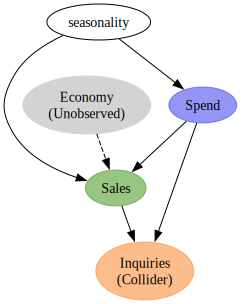

In [3]:
g = gr.Digraph()

g.node(name="seasonality", label="seasonality")
g.node(name="spend", label="Spend", color="#2a2eec80", style="filled")
g.node(name="sales", label="Sales", color="#328c0680", style="filled")
g.node(name="economy", label="Economy\n(Unobserved)", color="lightgrey", style="filled")
g.node(
    name="inquiries", label="Inquiries\n(Collider)", color="#fa7c1780", style="filled"
)

g.edge(tail_name="seasonality", head_name="spend")
g.edge(tail_name="seasonality", head_name="sales")
g.edge(tail_name="spend", head_name="sales")
g.edge(tail_name="economy", head_name="sales", style="dashed")
g.edge(tail_name="spend", head_name="inquiries")
g.edge(tail_name="sales", head_name="inquiries")

g

## Data Generating Process

We generate $n = 200$ weeks of data according to the causal graph above. The **true causal effect** of spend on sales is $\beta_{\text{spend}} = 3$. The variable `economy` affects sales but is **not included** in either regression, introducing realistic unexplained variance. The variable `inquiries` is a collider (common effect of spend and sales).

In [4]:
class Simulator(BaseModel):
    model_config = ConfigDict(arbitrary_types_allowed=True)

    rng: np.random.Generator = Field(..., description="NumPy random number generator.")
    n: int = Field(default=200, description="Number of time periods (weeks).", gt=0)
    true_intercept: float = Field(
        default=10.0, description="Intercept in the sales equation."
    )
    true_beta_spend: float = Field(
        default=3.0, description="True causal effect of spend on sales."
    )
    true_beta_seasonality: float = Field(
        default=5.0, description="Effect of seasonality on sales."
    )
    true_beta_economy: float = Field(
        default=4.0, description="Effect of the unobserved economy variable on sales."
    )
    spend_offset: float = Field(
        default=5.0, description="Baseline level of marketing spend."
    )
    spend_seasonality_coeff: float = Field(
        default=0.5, description="How much seasonality drives spend."
    )
    spend_noise_scale: float = Field(
        default=0.5, description="Noise std for marketing spend.", gt=0
    )
    economy_noise_scale: float = Field(
        default=1.0, description="Noise std for the unobserved economy variable.", gt=0
    )
    sales_noise_scale: float = Field(
        default=1.0, description="Noise std for sales.", gt=0
    )
    inquiries_spend_coeff: float = Field(
        default=2.0, description="How much spend drives inquiries (collider)."
    )
    inquiries_sales_coeff: float = Field(
        default=0.4, description="How much sales drives inquiries (collider)."
    )
    inquiries_noise_scale: float = Field(
        default=2.0, description="Noise std for inquiries.", gt=0
    )

    def run(self) -> pl.DataFrame:
        t = np.arange(self.n)
        seasonality = np.sin(2 * np.pi * t / 52) + 0.3 * np.cos(3 * np.pi * t / 52)

        spend = (
            self.spend_offset
            + self.spend_seasonality_coeff * seasonality
            + self.rng.normal(loc=0, scale=self.spend_noise_scale, size=self.n)
        )

        economy = self.rng.normal(loc=0, scale=self.economy_noise_scale, size=self.n)

        sales = (
            self.true_intercept
            + self.true_beta_spend * spend
            + self.true_beta_seasonality * seasonality
            + self.true_beta_economy * economy
            + self.rng.normal(loc=0, scale=self.sales_noise_scale, size=self.n)
        )

        inquiries = (
            self.inquiries_spend_coeff * spend
            + self.inquiries_sales_coeff * sales
            + self.rng.normal(loc=0, scale=self.inquiries_noise_scale, size=self.n)
        )

        return pl.DataFrame(
            {
                "t": t,
                "seasonality": seasonality,
                "spend": spend,
                "economy": economy,
                "sales": sales,
                "inquiries": inquiries,
            }
        )

Let's run the simulation:

In [5]:
simulator = Simulator(rng=rng)

df = simulator.run()

df.head(10)

t,seasonality,spend,economy,sales,inquiries
i64,f64,f64,f64,f64,f64
0,0.3,5.202157,0.368769,27.854163,23.569654
1,0.415623,5.608521,0.568056,29.74437,19.359844
2,0.519821,5.882141,-0.701665,26.591568,25.361389
3,0.611339,4.26285,-0.094421,24.897489,21.055961
4,0.689276,4.946351,0.127401,29.047779,22.807212
5,0.75308,5.566801,0.954376,35.987948,26.927716
6,0.80254,4.559117,0.284881,26.895575,18.193614
7,0.837762,5.273219,-0.817643,26.896495,20.199277
8,0.859145,6.468036,-1.209203,28.063207,22.386155


## Visualize the Data

Before fitting any models, let's visualize the data (please, never start modeling without visualizing the data!).

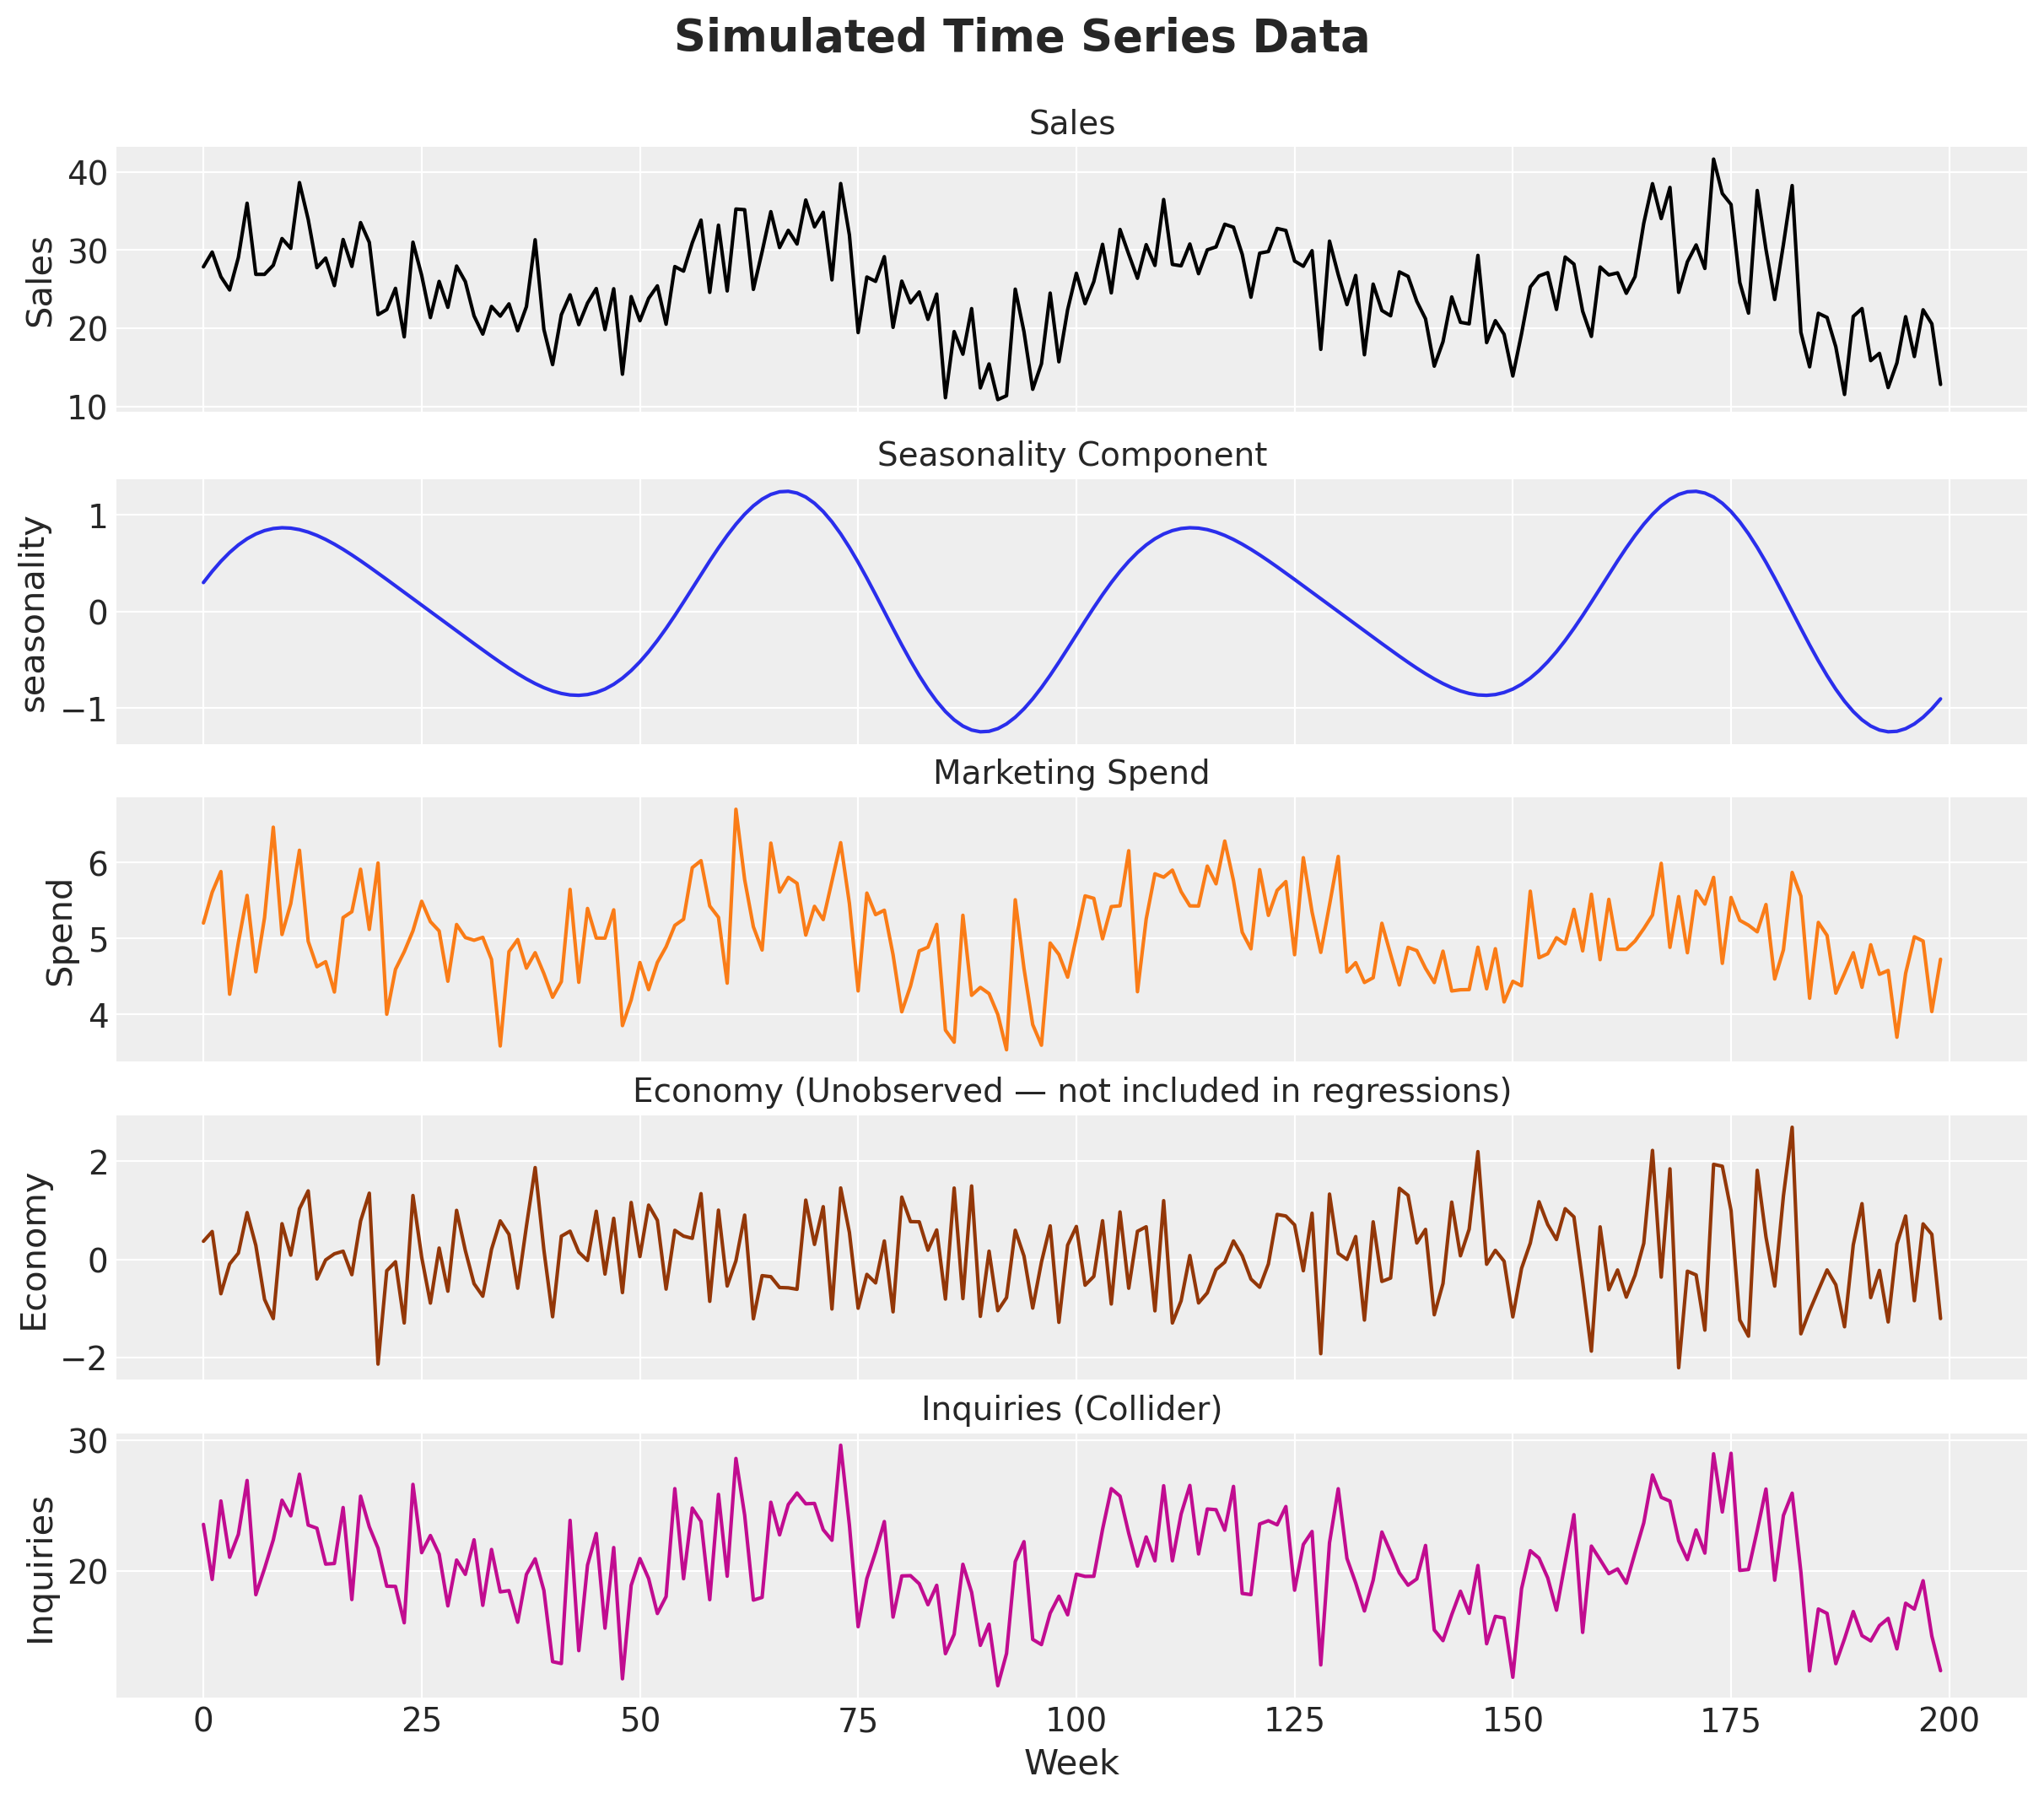

In [6]:
fig, axes = plt.subplots(
    nrows=5,
    ncols=1,
    figsize=(12, 10),
    sharex=True,
    sharey=False,
    layout="constrained",
)


axes[0].plot(df["t"], df["sales"], color="black")
axes[0].set(ylabel="Sales")
axes[0].set_title("Sales", fontsize=14)

axes[1].plot(df["t"], df["seasonality"], color="C0")
axes[1].set(ylabel="seasonality")
axes[1].set_title("Seasonality Component", fontsize=14)

axes[2].plot(df["t"], df["spend"], color="C1")
axes[2].set(ylabel="Spend")
axes[2].set_title("Marketing Spend", fontsize=14)

axes[3].plot(df["t"], df["economy"], color="C4")
axes[3].set(ylabel="Economy")
axes[3].set_title("Economy (Unobserved — not included in regressions)", fontsize=14)

axes[4].plot(df["t"], df["inquiries"], color="C3")
axes[4].set(ylabel="Inquiries")
axes[4].set_title("Inquiries (Collider)", fontsize=14)

axes[4].set_xlabel("Week")

fig.suptitle("Simulated Time Series Data", fontsize=19, fontweight="bold", y=1.05);

We can verify that the variables of interest are correlated:

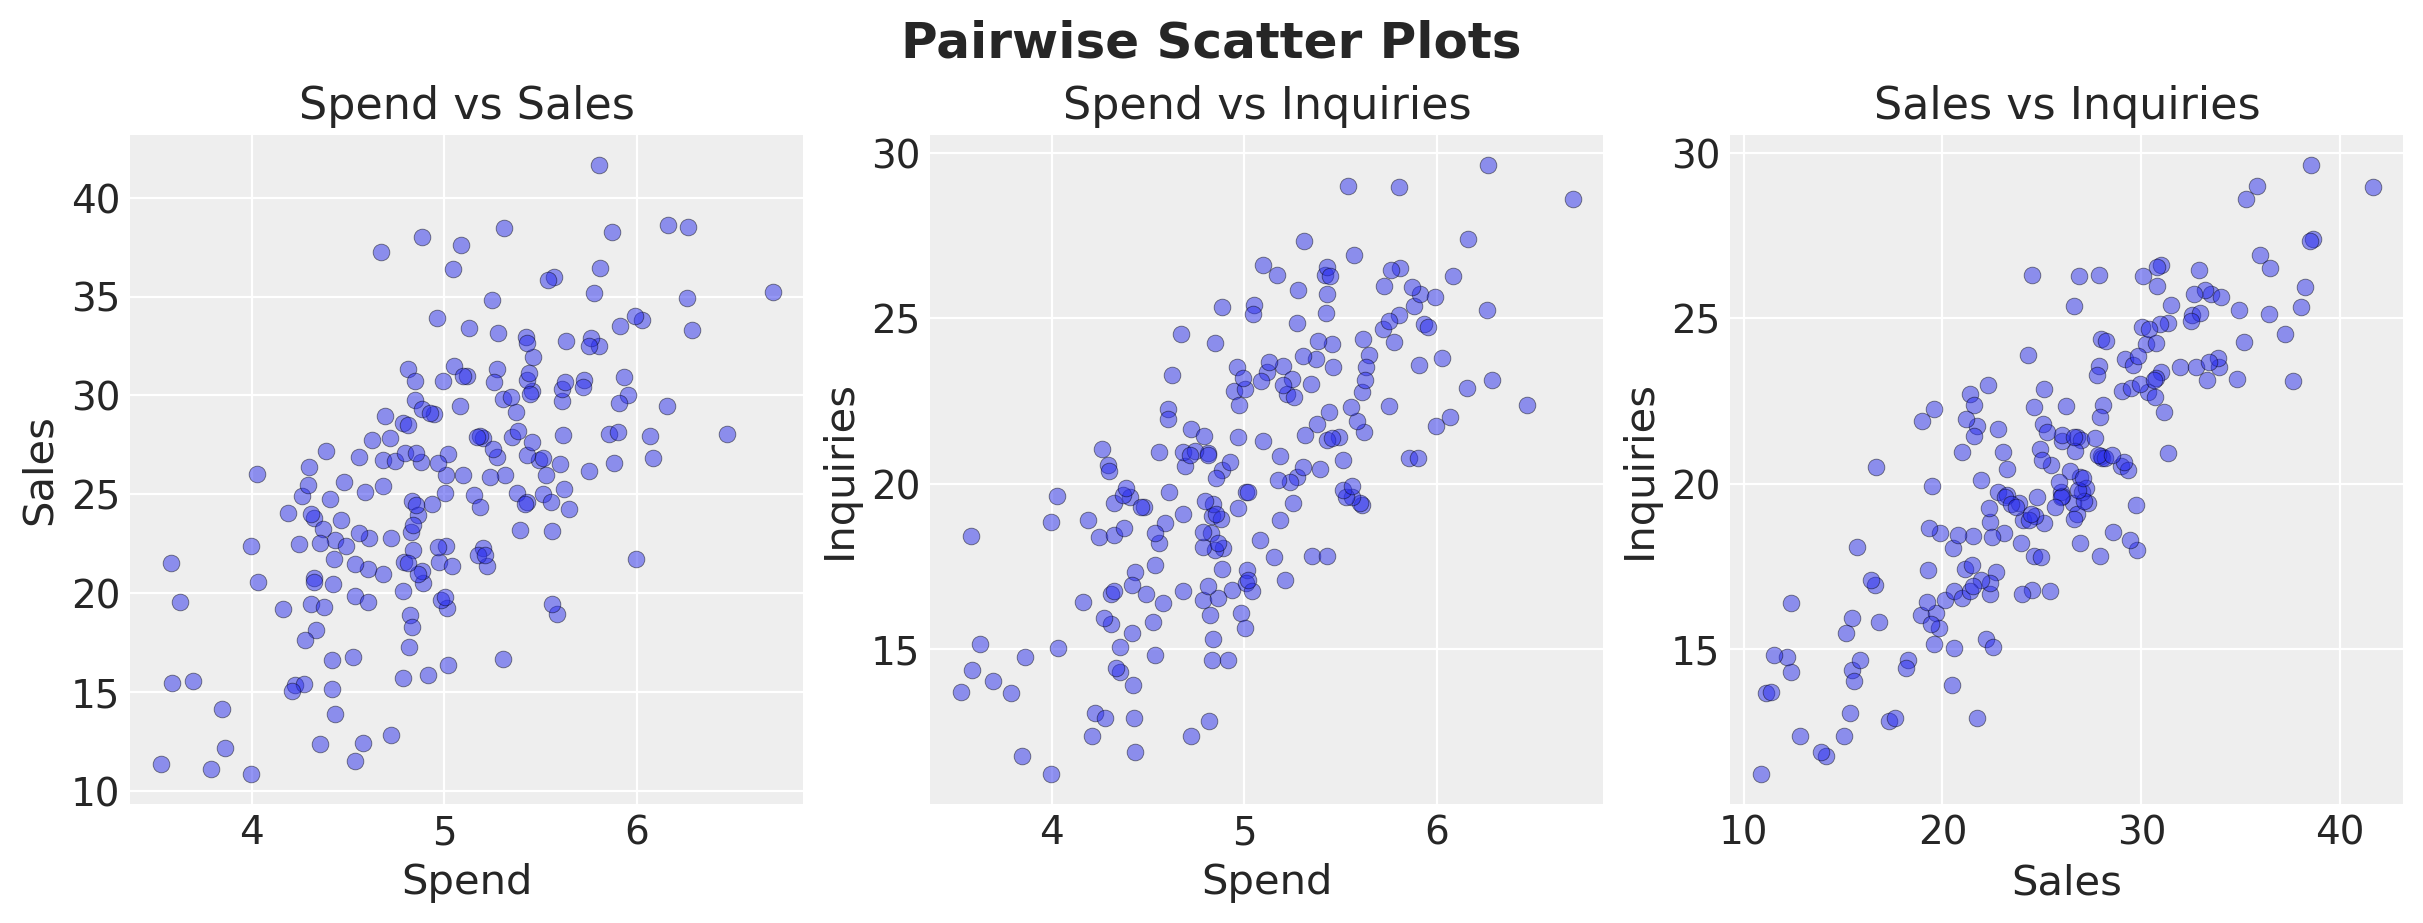

In [7]:
fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(12, 4.5), layout="constrained")

axes[0].scatter(df["spend"], df["sales"], alpha=0.5, edgecolors="k", linewidths=0.3)
axes[0].set(xlabel="Spend", ylabel="Sales", title="Spend vs Sales")

axes[1].scatter(df["spend"], df["inquiries"], alpha=0.5, edgecolors="k", linewidths=0.3)
axes[1].set(xlabel="Spend", ylabel="Inquiries", title="Spend vs Inquiries")

axes[2].scatter(df["sales"], df["inquiries"], alpha=0.5, edgecolors="k", linewidths=0.3)
axes[2].set(xlabel="Sales", ylabel="Inquiries", title="Sales vs Inquiries")

fig.suptitle("Pairwise Scatter Plots", fontsize=18, fontweight="bold");

## Fit Both Models

We fit two Bayesian linear regressions using [bambi](https://bambinos.github.io/bambi/):

- **Model A (Correct):** `sales ~ spend + seasonality`
  — the correct structural model.
- **Model B (Collider):** `sales ~ spend + seasonality + inquiries`
  — includes the collider.

### Model A: Correct Structural Model

In [8]:
df_pd = df.to_pandas()

priors = {
    "Intercept": bmb.Prior("Normal", mu=1, sigma=5),
    # We can enforce a non-negative prior for spend
    "spend": bmb.Prior("HalfNormal", sigma=1),
    "seasonality": bmb.Prior("Normal", mu=0, sigma=5),
    "sigma": bmb.Prior("Exponential", lam=1),
}

model_a = bmb.Model("sales ~ spend + seasonality", data=df_pd, priors=priors)
idata_a = model_a.fit(
    draws=2_000,
    tune=1_000,
    chains=4,
    target_accept=0.85,
    random_seed=rng,
)
model_a.predict(idata_a, kind="response")

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [sigma, Intercept, spend, seasonality]


Output()

Sampling 4 chains for 1_000 tune and 2_000 draw iterations (4_000 + 8_000 draws total) took 1 seconds.


In [9]:
az.summary(
    idata_a,
    var_names=["Intercept", "spend", "seasonality", "sigma"],
)

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
Intercept,12.472,2.381,8.034,16.968,0.031,0.028,6084.0,4675.0,1.0
spend,2.558,0.471,1.636,3.409,0.006,0.006,5993.0,4706.0,1.0
seasonality,5.058,0.421,4.242,5.832,0.005,0.004,6160.0,6371.0,1.0
sigma,3.881,0.196,3.524,4.255,0.002,0.002,7131.0,6284.0,1.0


### Model B: Collider Model (includes `inquiries`)

In [10]:
priors = {
    "Intercept": bmb.Prior("Normal", mu=1, sigma=5),
    "spend": bmb.Prior("HalfNormal", sigma=1),
    "seasonality": bmb.Prior("Normal", mu=0, sigma=5),
    "inquiries": bmb.Prior("Normal", mu=0, sigma=1),
    "sigma": bmb.Prior("Exponential", lam=1),
}

model_b = bmb.Model(
    "sales ~ spend + seasonality + inquiries", data=df_pd, priors=priors
)
idata_b = model_b.fit(
    draws=2_000,
    tune=1_000,
    chains=4,
    target_accept=0.85,
    random_seed=rng,
)
model_b.predict(idata_b, kind="response")

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [sigma, Intercept, spend, seasonality, inquiries]


Output()

Sampling 4 chains for 1_000 tune and 2_000 draw iterations (4_000 + 8_000 draws total) took 1 seconds.


In [11]:
az.summary(
    idata_b,
    var_names=["Intercept", "spend", "seasonality", "inquiries", "sigma"],
)

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
Intercept,3.817,1.729,0.397,6.995,0.022,0.017,6020.0,6223.0,1.0
spend,0.425,0.304,0.000,0.965,0.004,0.004,3130.0,2129.0,1.0
seasonality,2.757,0.373,2.054,3.451,0.005,0.004,4952.0,5070.0,1.0
inquiries,0.953,0.077,0.802,1.092,0.001,0.001,4179.0,4679.0,1.0
sigma,3.005,0.151,2.730,3.297,0.002,0.002,6334.0,5402.0,1.0


## Compare Results

Let's compare the two models side by side on various aspects:
1. **In-sample fit.**
2. **[Bayesian $R^2$](https://www.tandfonline.com/doi/abs/10.1080/00031305.2018.1549100)**: how well does the model fit the data?
3. **Estimated causal effect of Spend**: how close is the
   posterior mean to the true $\beta_{\text{spend}} = 3$?

**Remark:** You can use frequentist models and the classical $R^2$ to make the same point. It does not make any difference.

Let's start with the in-sample fit.

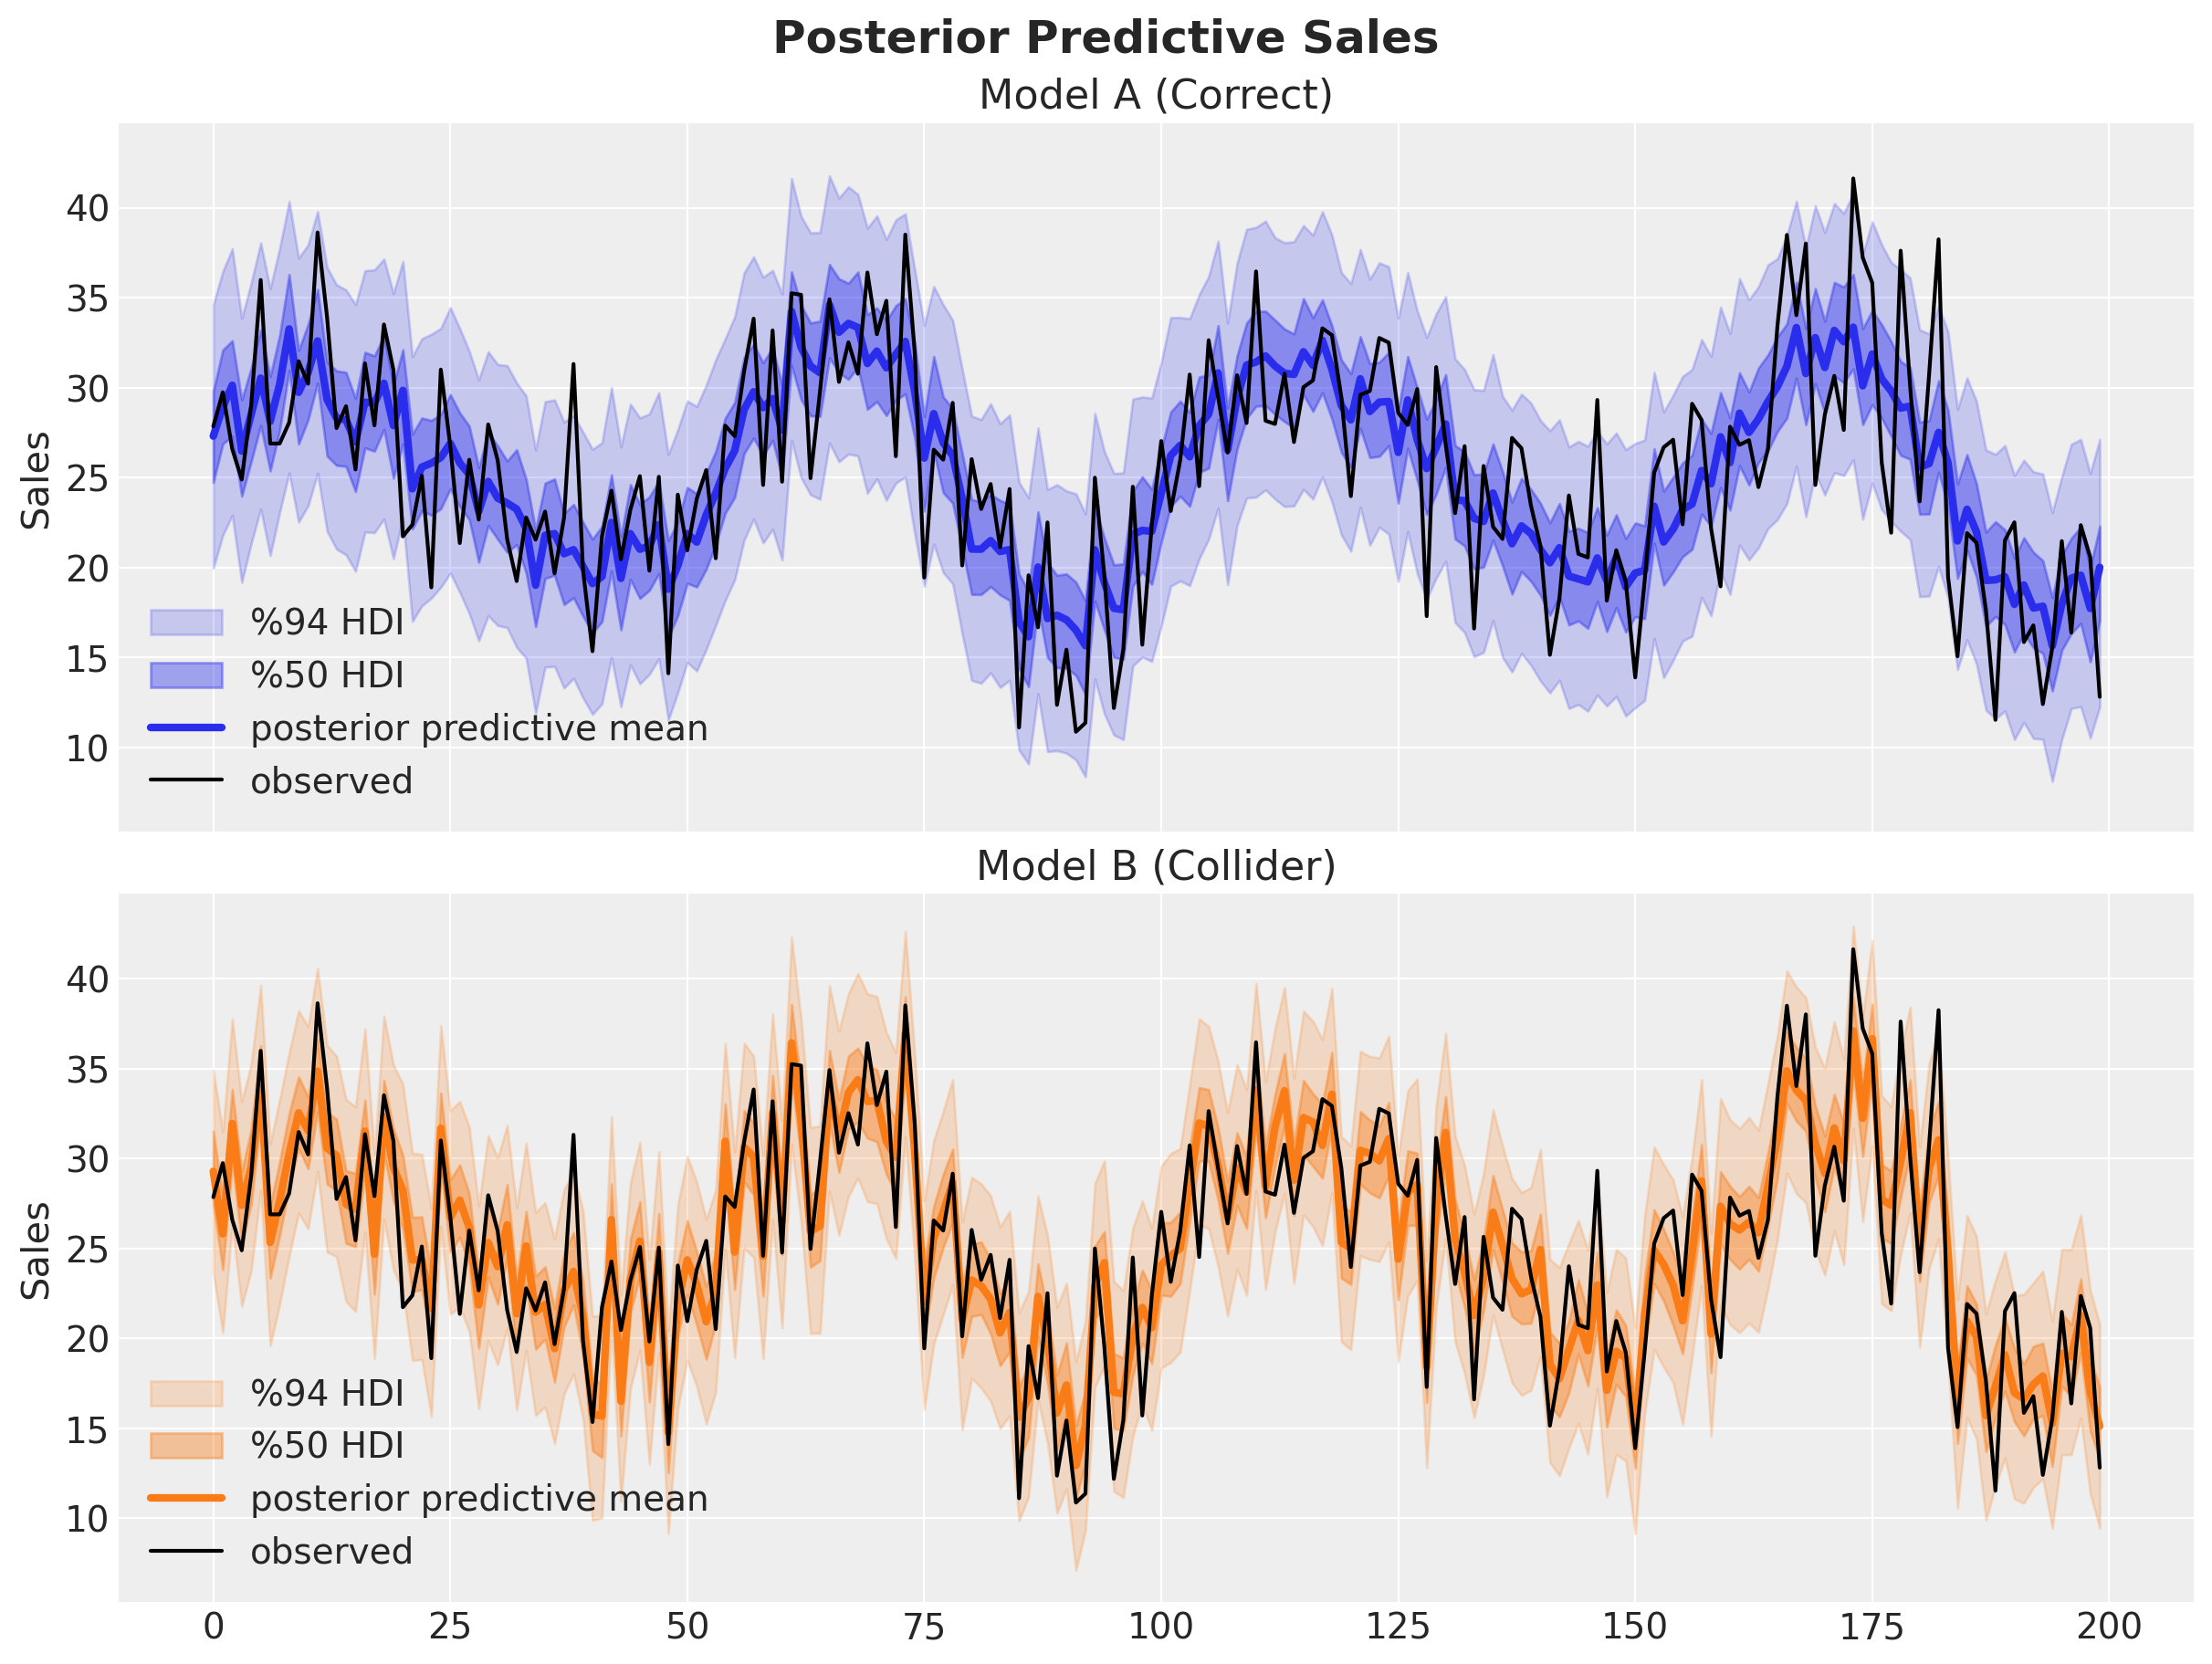

In [12]:
fig, axes = plt.subplots(
    nrows=2,
    ncols=1,
    figsize=(12, 9),
    sharex=True,
    sharey=True,
    layout="constrained",
)
az.plot_hdi(
    df["t"],
    idata_a["posterior_predictive"]["sales"],
    hdi_prob=0.94,
    smooth=False,
    fill_kwargs={"alpha": 0.2, "color": "C0", "label": "%94 HDI"},
    ax=axes[0],
)
az.plot_hdi(
    df["t"],
    idata_a["posterior_predictive"]["sales"],
    hdi_prob=0.5,
    smooth=False,
    fill_kwargs={"alpha": 0.4, "color": "C0", "label": "%50 HDI"},
    ax=axes[0],
)
axes[0].plot(
    df["t"],
    idata_a["posterior_predictive"]["sales"].mean(dim=("chain", "draw")),
    color="C0",
    linewidth=3,
    label="posterior predictive mean",
)
axes[0].plot(df["t"], df["sales"], color="black", label="observed")
axes[0].legend()
axes[0].set(title="Model A (Correct)", ylabel="Sales")

az.plot_hdi(
    df["t"],
    idata_b["posterior_predictive"]["sales"],
    hdi_prob=0.94,
    fill_kwargs={"alpha": 0.2, "color": "C1", "label": "%94 HDI"},
    smooth=False,
    ax=axes[1],
)
az.plot_hdi(
    df["t"],
    idata_b["posterior_predictive"]["sales"],
    hdi_prob=0.5,
    fill_kwargs={"alpha": 0.4, "color": "C1", "label": "%50 HDI"},
    smooth=False,
    ax=axes[1],
)
axes[1].plot(
    df["t"],
    idata_b["posterior_predictive"]["sales"].mean(dim=("chain", "draw")),
    color="C1",
    linewidth=3,
    label="posterior predictive mean",
)
axes[1].plot(df["t"], df["sales"], color="black", label="observed")
axes[1].legend()
axes[1].set(title="Model B (Collider)", ylabel="Sales")
fig.suptitle("Posterior Predictive Sales", fontsize=18, fontweight="bold");

Visually, Model B seems to fit the data better than Model A. Let's quantify this through Bayesian $R^2$.

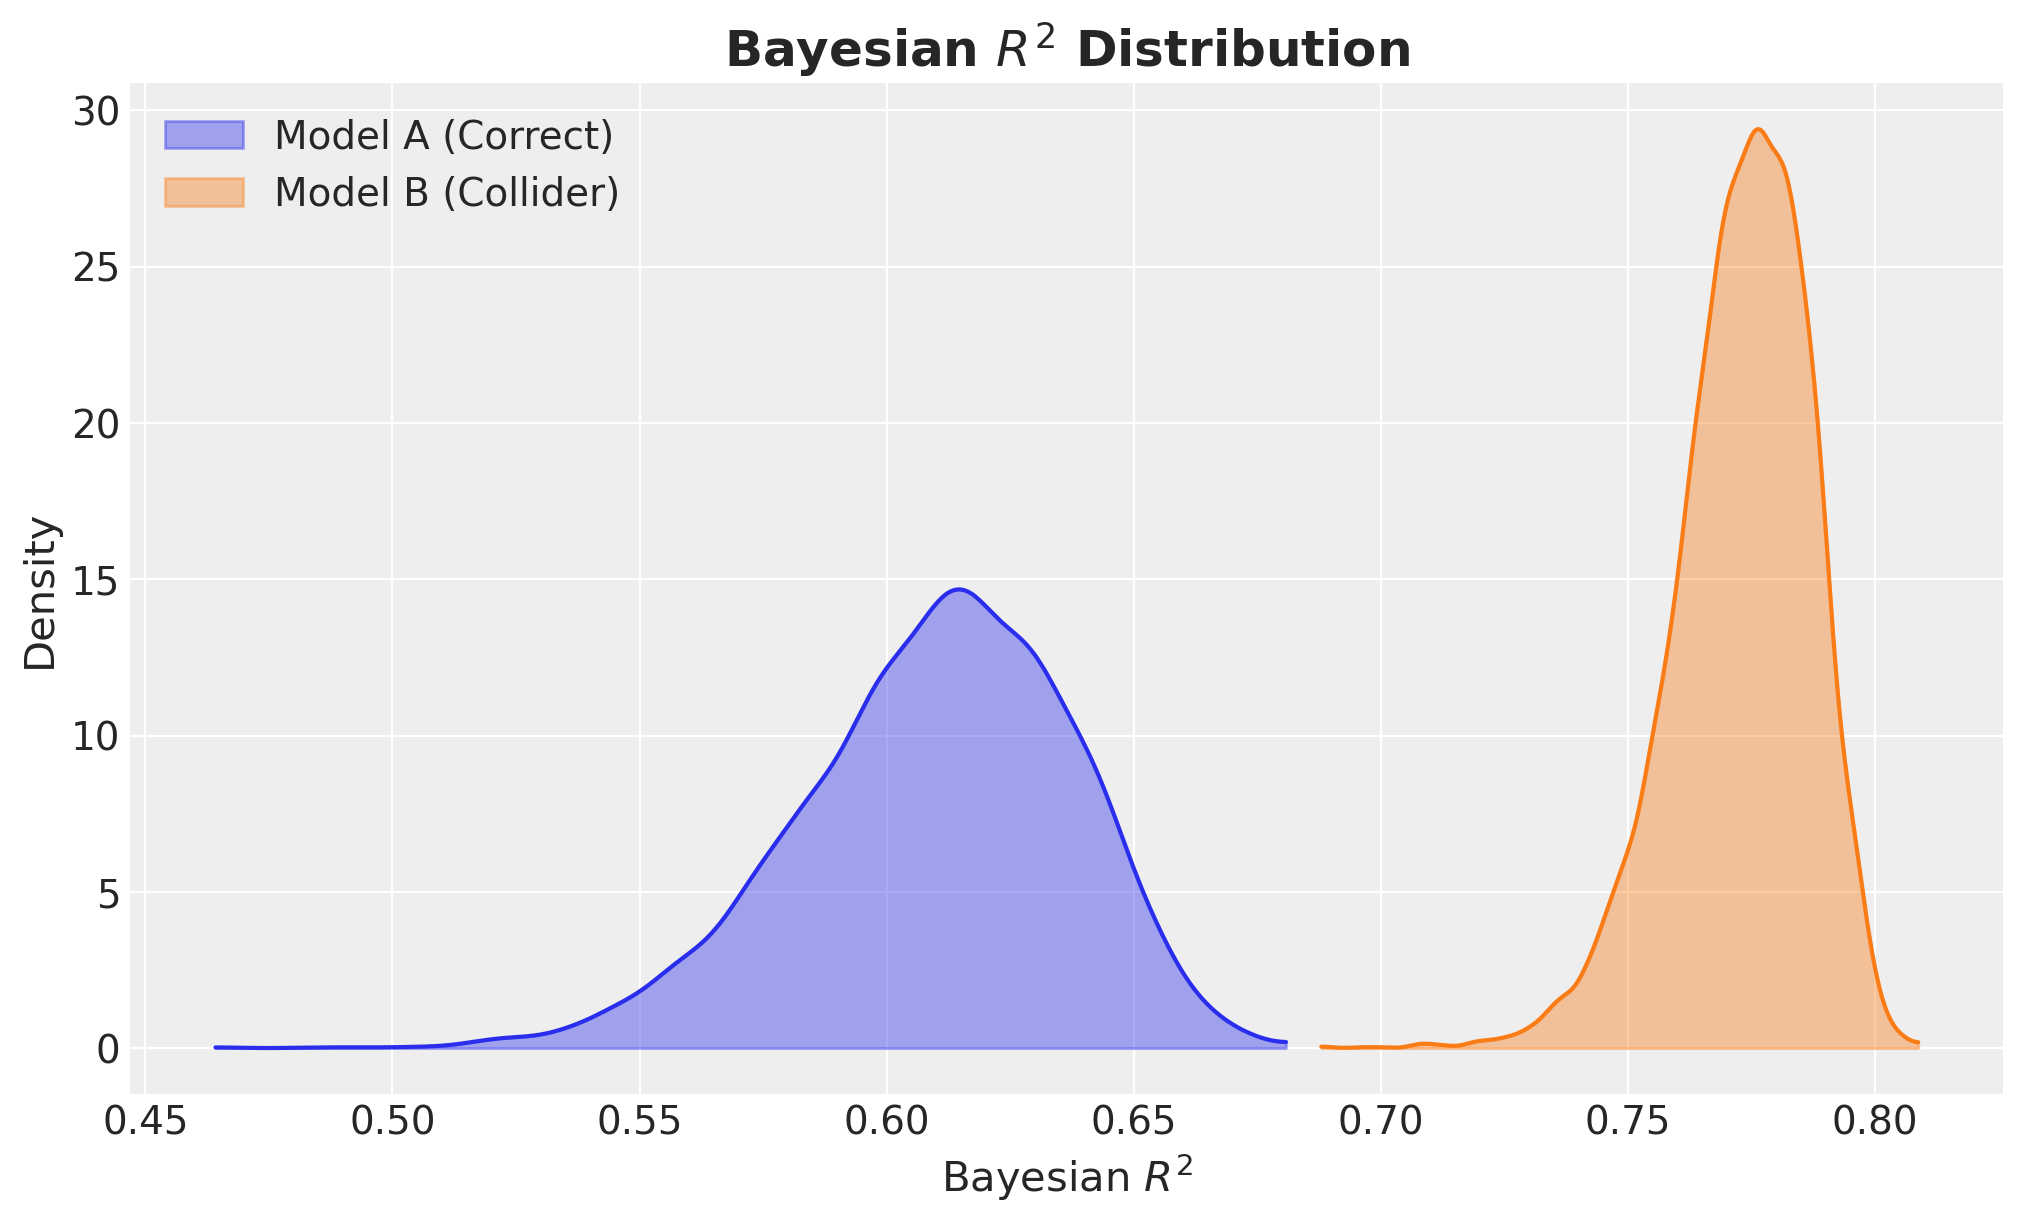

In [13]:
r2_a = model_a.r2_score(idata_a, summary=False)
r2_b = model_b.r2_score(idata_b, summary=False)

fig, ax = plt.subplots()
az.plot_dist(
    r2_a,
    color="C0",
    fill_kwargs={"alpha": 0.4, "label": "Model A (Correct)"},
    ax=ax,
)
az.plot_dist(
    r2_b,
    color="C1",
    fill_kwargs={"alpha": 0.4, "label": "Model B (Collider)"},
    ax=ax,
)
ax.legend()
ax.set(xlabel="Bayesian $R^2$", ylabel="Density")
ax.set_title("Bayesian $R^2$ Distribution", fontsize=18, fontweight="bold");

Wow! Model B has a much higher $R^2$! It is even close to the magic number of $0.8$! I would bet that around $95%$ of senior decision makers would ditch Model A and use Model B as a no-brainer. I mean, the relative improvement in $R^2$ is around $25%$, so please take Model B and give me a raise ¯\\_(ツ)_/¯!



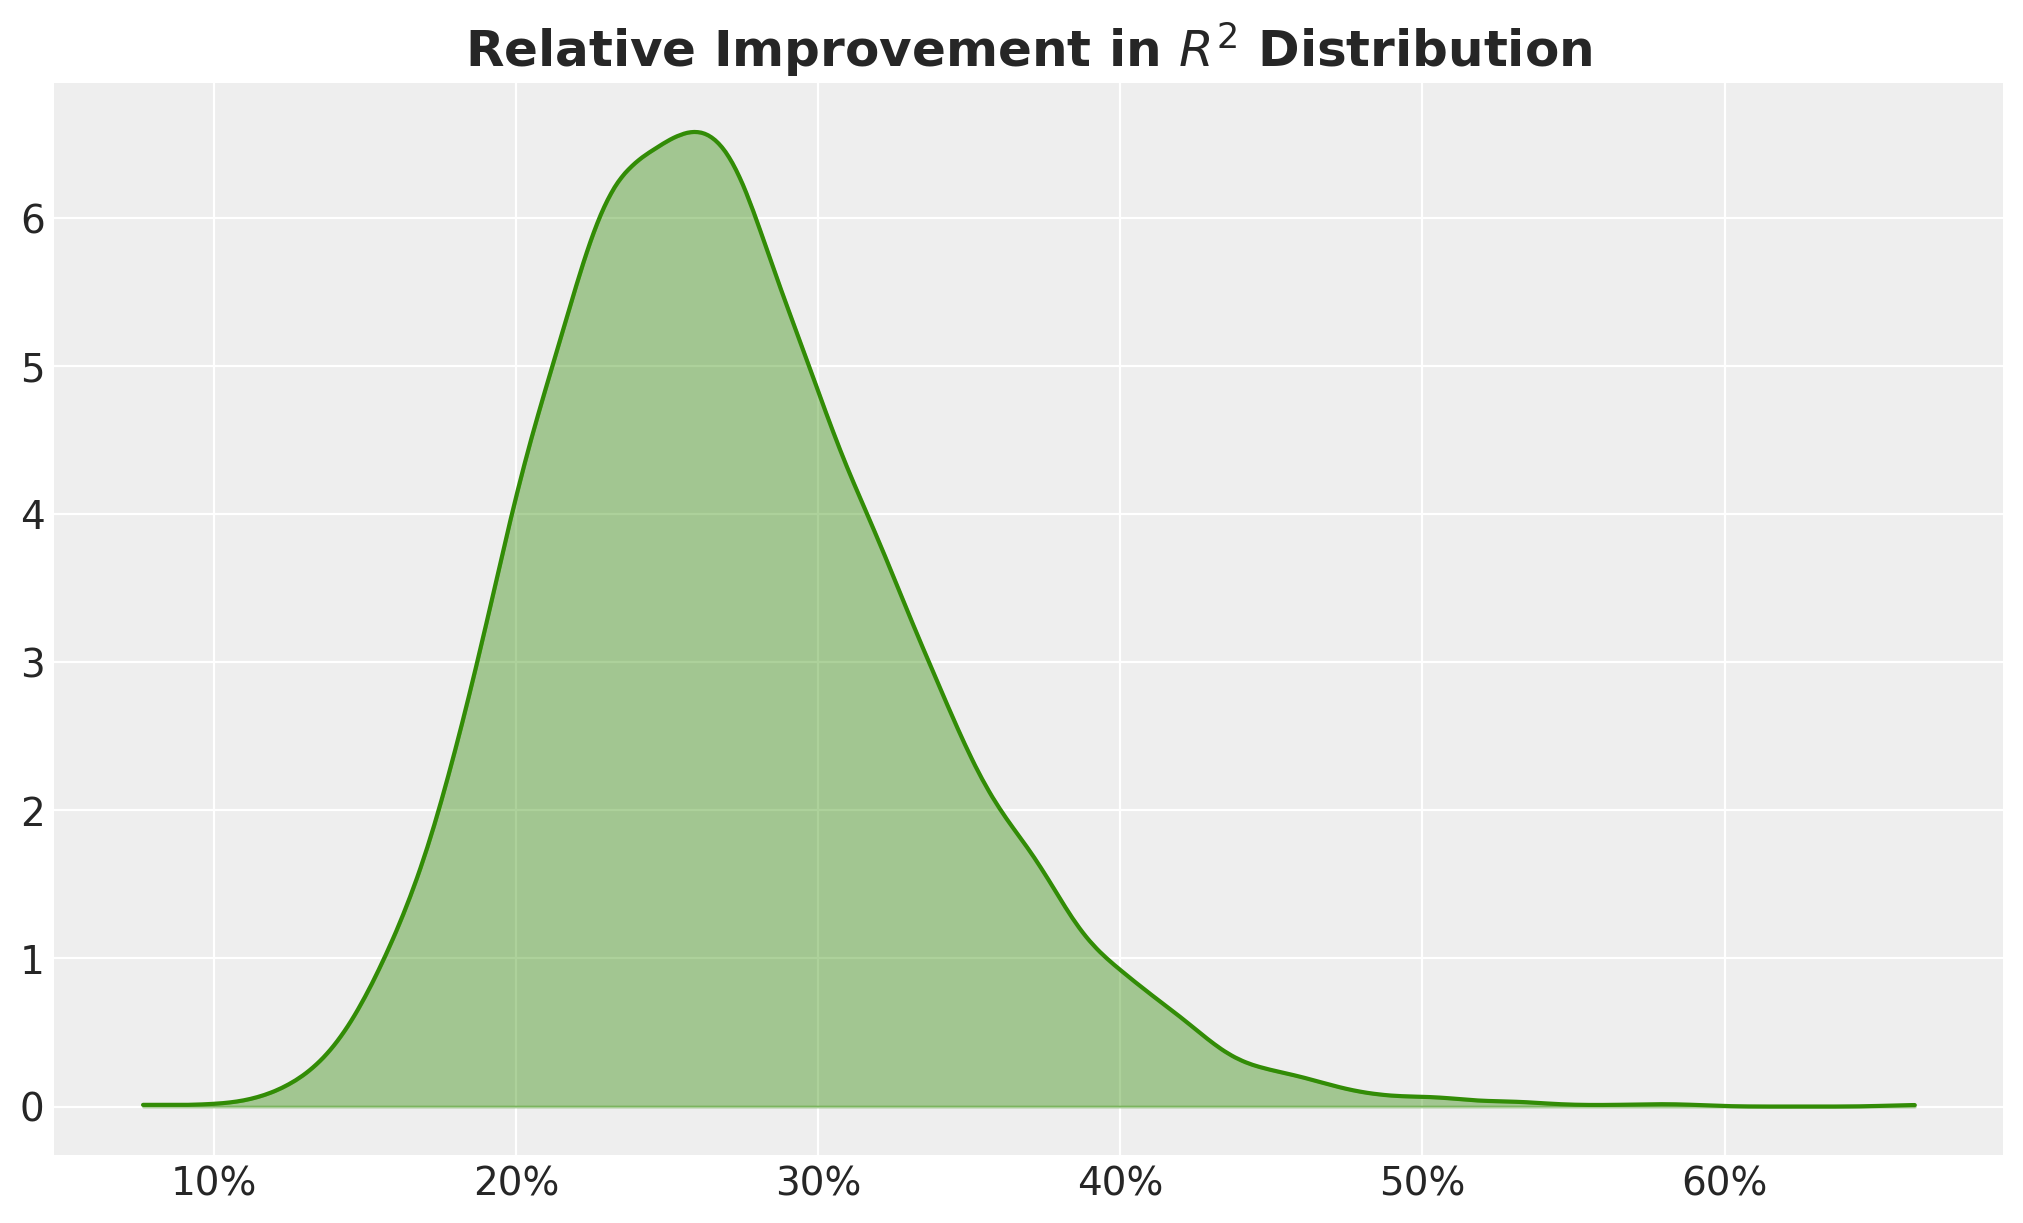

In [14]:
fig, ax = plt.subplots()
az.plot_dist(
    r2_b / r2_a - 1,
    color="C2",
    fill_kwargs={"alpha": 0.4},
    ax=ax,
)
ax.xaxis.set_major_formatter(mtick.PercentFormatter(xmax=1))
ax.set_title(
    "Relative Improvement in $R^2$ Distribution", fontsize=18, fontweight="bold"
);

**Key Observation:** Model B (with the collider) has a **higher** $R^2$ but a **biased** estimate of the causal effect of Spend. The collider variable `inquiries` absorbs variation in Sales (because it is partly caused by Sales), inflating $R^2$. But conditioning on it opens a spurious path, distorting the coefficient on Spend.

We can confirm this by looking at the posterior distribution of the regression coefficient of Spend.

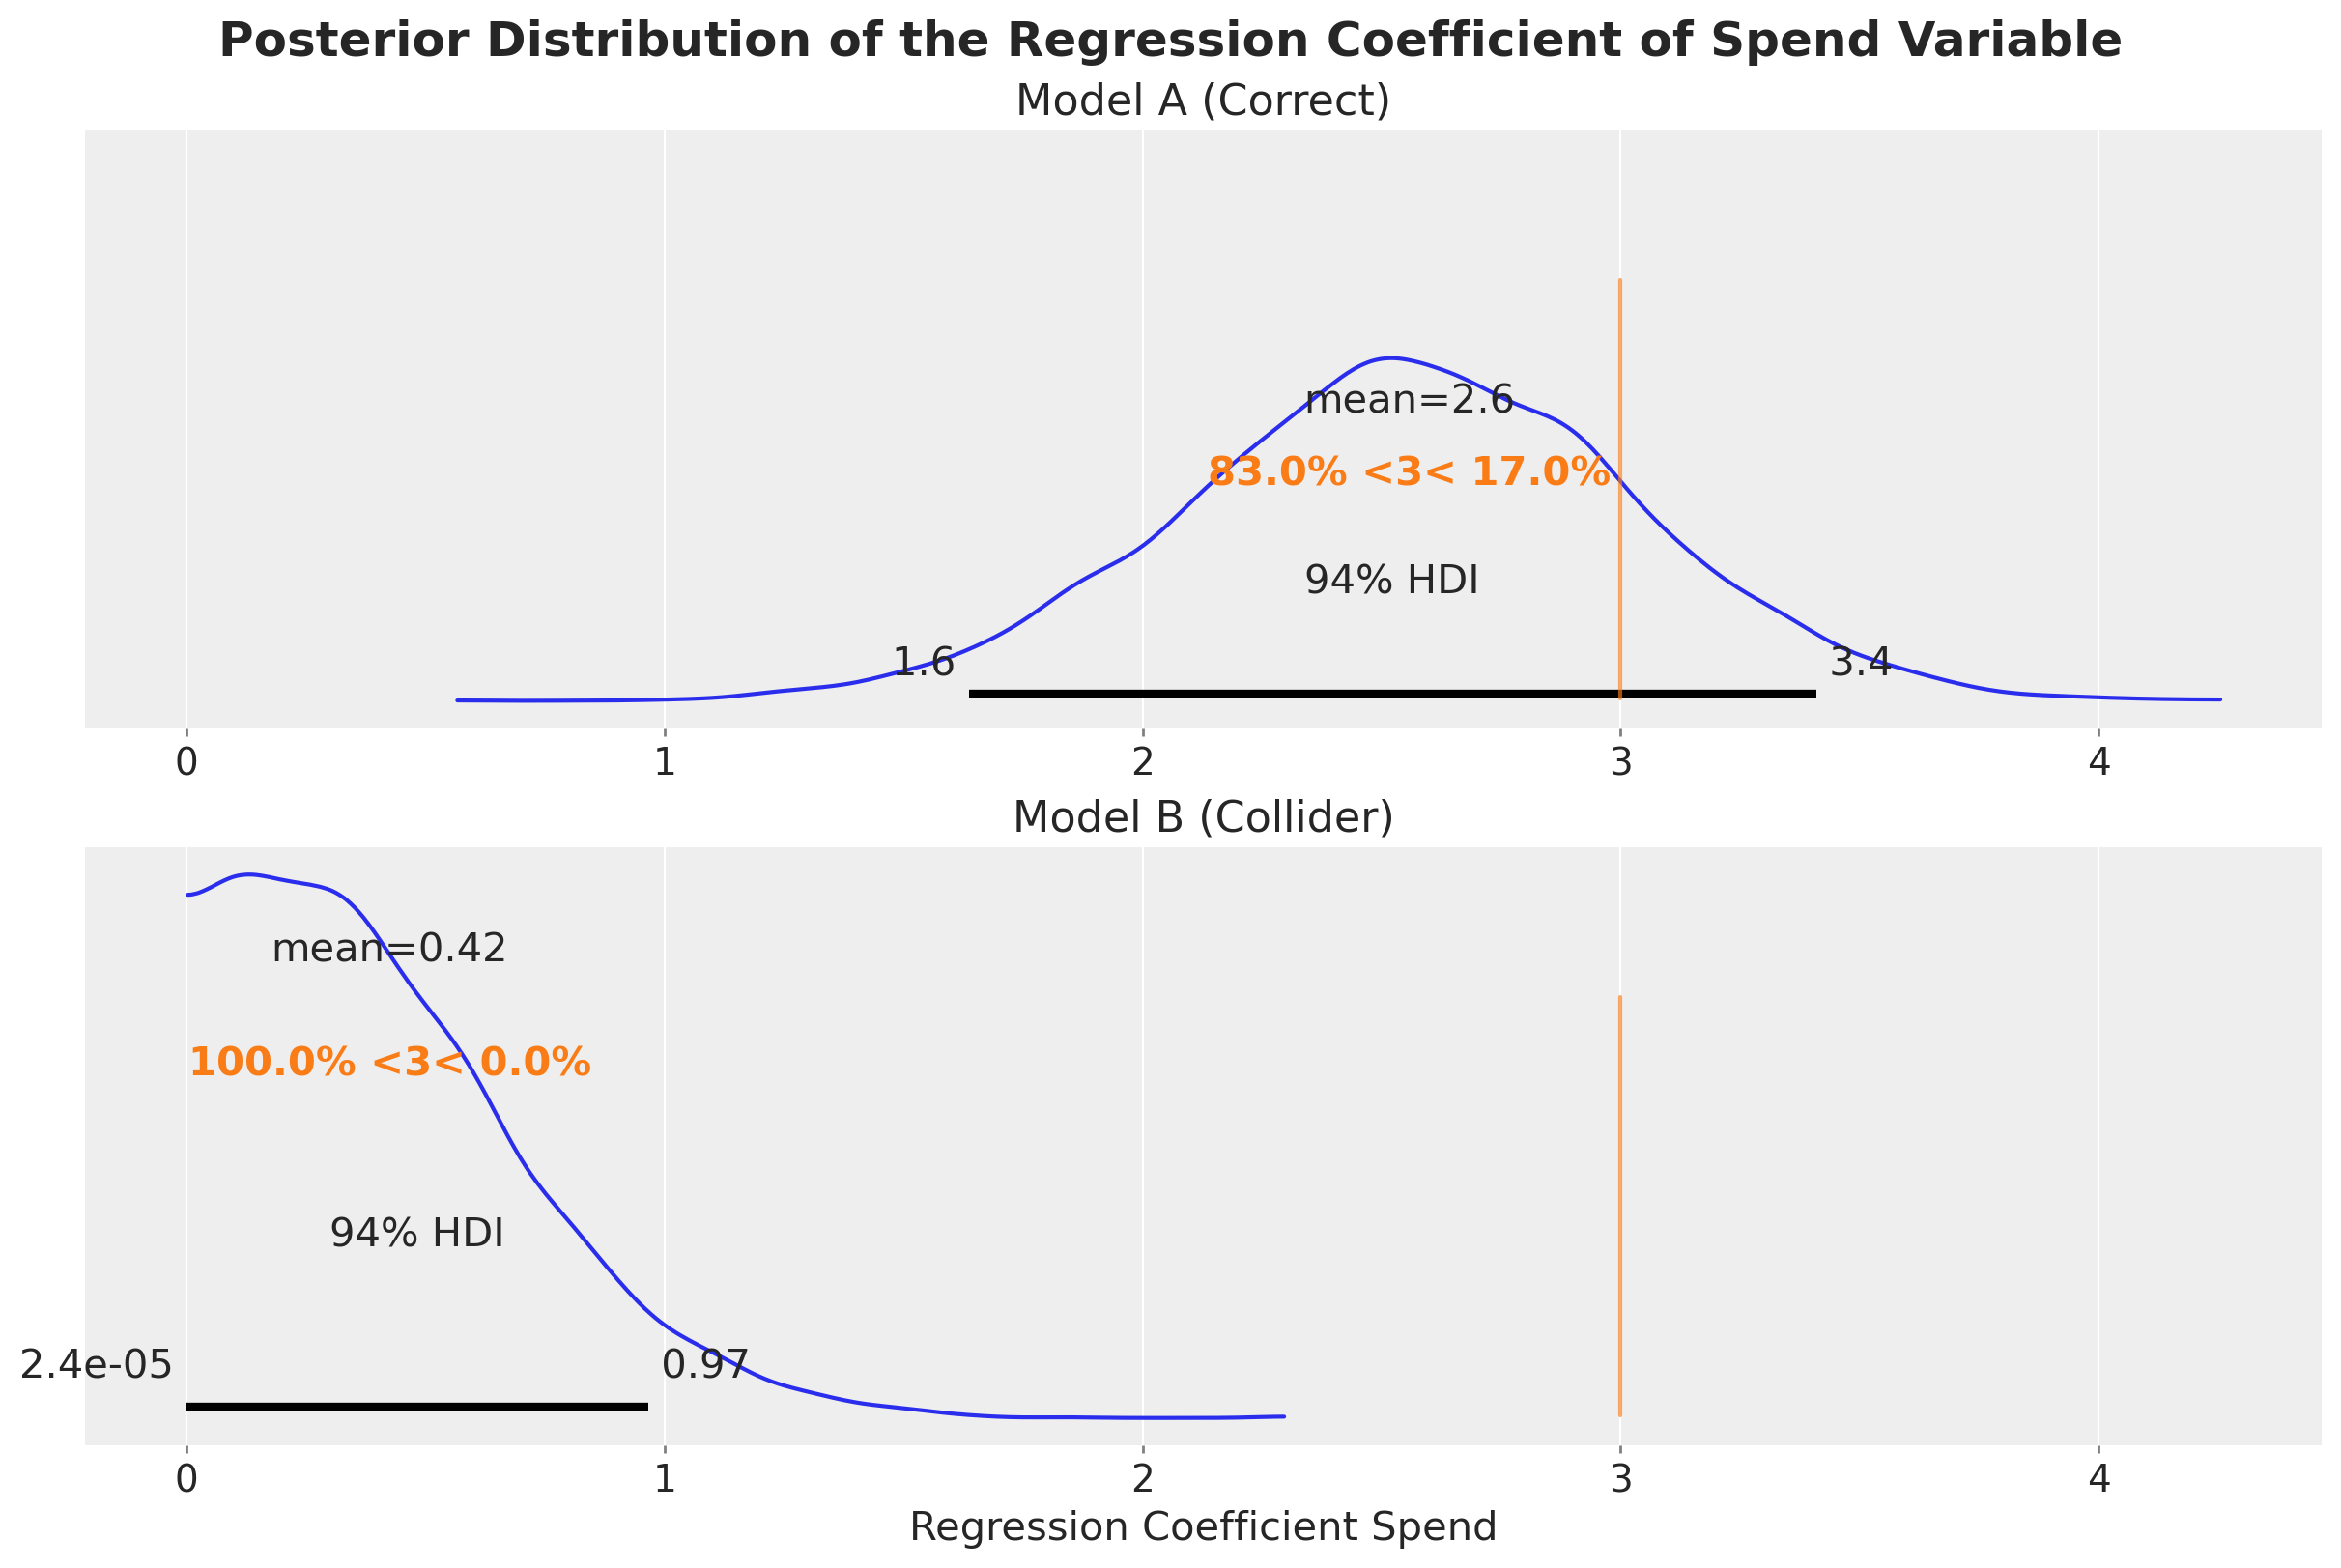

In [15]:
fig, axes = plt.subplots(
    nrows=2,
    ncols=1,
    figsize=(12, 8),
    sharex=True,
    sharey=True,
    layout="constrained",
)
az.plot_posterior(
    idata_a["posterior"]["spend"], ref_val=simulator.true_beta_spend, ax=axes[0]
)
az.plot_posterior(
    idata_b["posterior"]["spend"], ref_val=simulator.true_beta_spend, ax=axes[1]
)
axes[0].set(
    title="Model A (Correct)",
)
axes[1].set(title="Model B (Collider)", xlabel="Regression Coefficient Spend")
fig.suptitle(
    "Posterior Distribution of the Regression Coefficient of Spend Variable",
    fontsize=18,
    fontweight="bold",
);

Well, no surprise here. The collider variable `inquiries` does a lot of harm. Model B estimates almost zero causal effect of Spend on Sales.

## Decision-Making Simulation

Ok! Fine! We are "a bit wrong" but the $R^2$ is high for Model B. How bad can it be? 🤦

To understand the implications of this, let's look at the expected effect of Spend on Sales (by leaving the other covariates constant and the mean).

Default computed for conditional variable: spend
Default computed for unspecified variable: seasonality
Default computed for conditional variable: spend
Default computed for unspecified variable: inquiries, seasonality


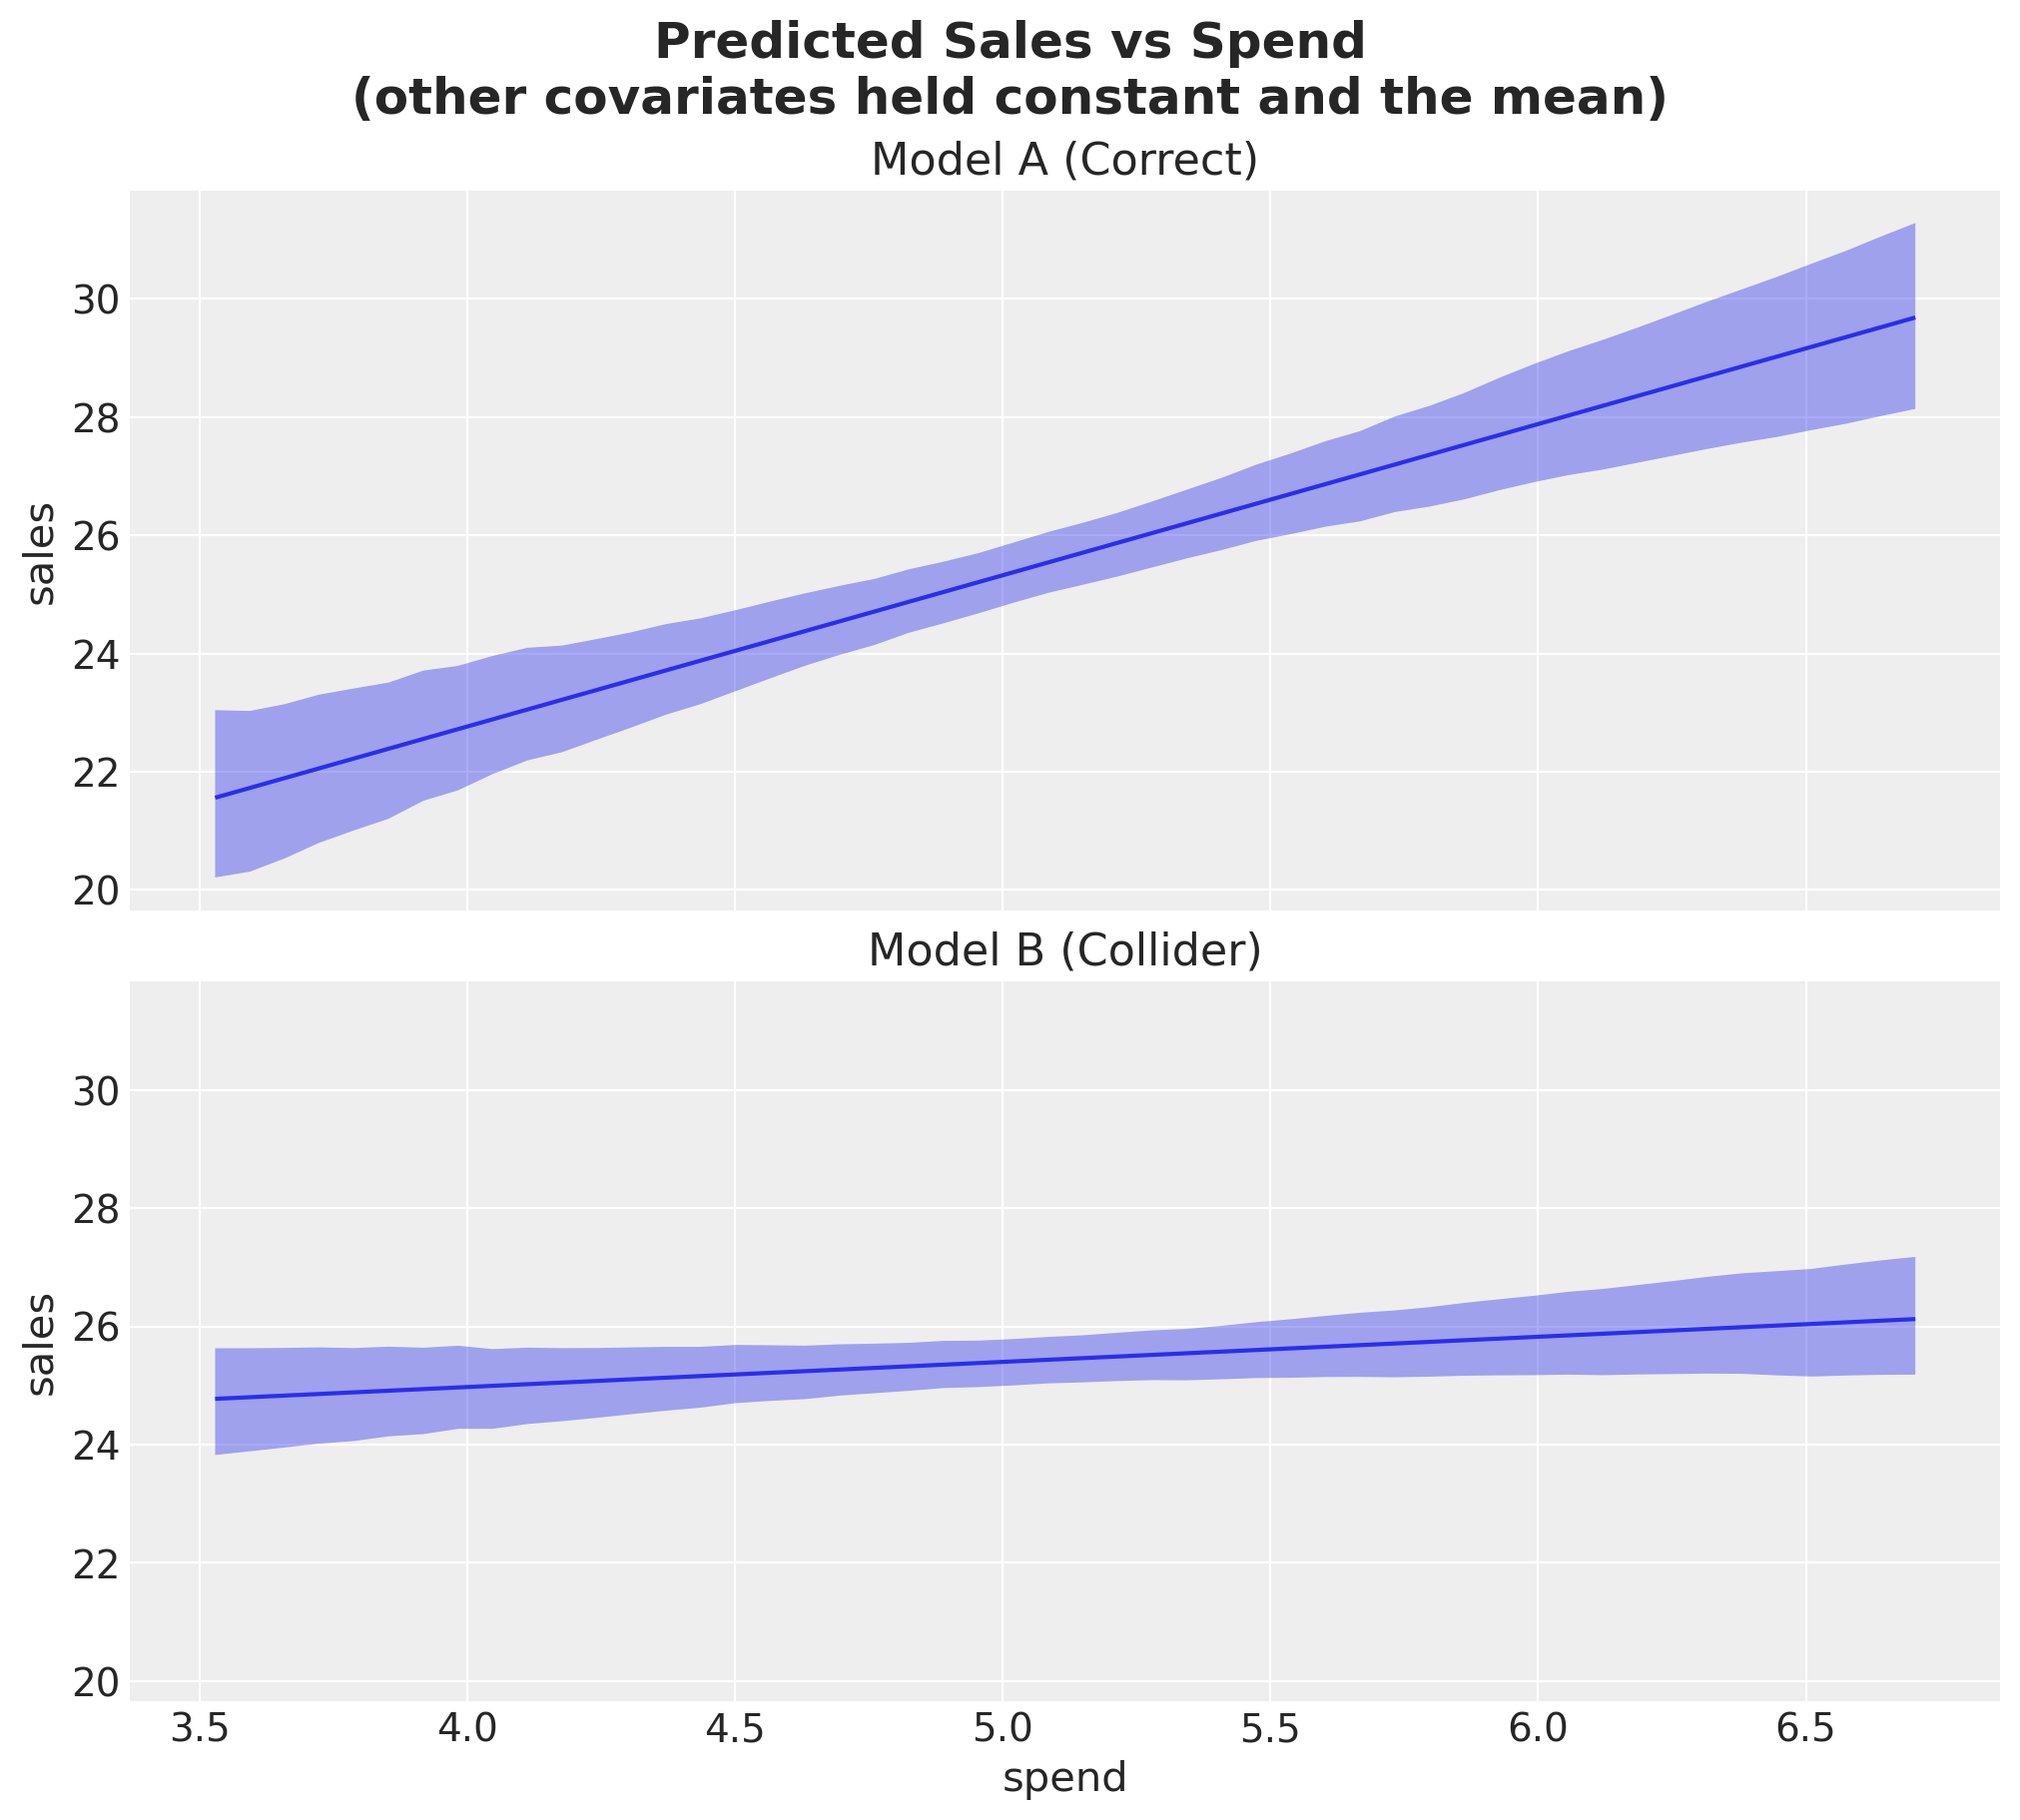

In [16]:
fig, axes = plt.subplots(
    nrows=2,
    ncols=1,
    figsize=(10, 9),
    sharex=True,
    sharey=True,
    layout="constrained",
)

bmb.interpret.plot_predictions(
    model_a,
    idata_a,
    "spend",
    subplot_kwargs={"color": "C0"},
    ax=axes[0],
)
axes[0].set(title="Model A (Correct)", xlabel=None)

bmb.interpret.plot_predictions(
    model_b,
    idata_b,
    "spend",
    subplot_kwargs={"color": "C1"},
    ax=axes[1],
)
axes[1].set(title="Model B (Collider)")

fig.suptitle(
    "Predicted Sales vs Spend\n(other covariates held constant and the mean)",
    fontsize=18,
    fontweight="bold",
);

No matter how much you spend, Model B predicts almost no additional sales. 

We can even go further and make a little simulation: suppose a decision maker asks: *"So, what would have happened if we increased marketing spend by $\delta = 5$ units on each period?"*

The true answer is $\delta \times \beta_1 = 5 \times 3 = 15$. In absolute numbers, we need to multiply this value by the number of periods in the data.

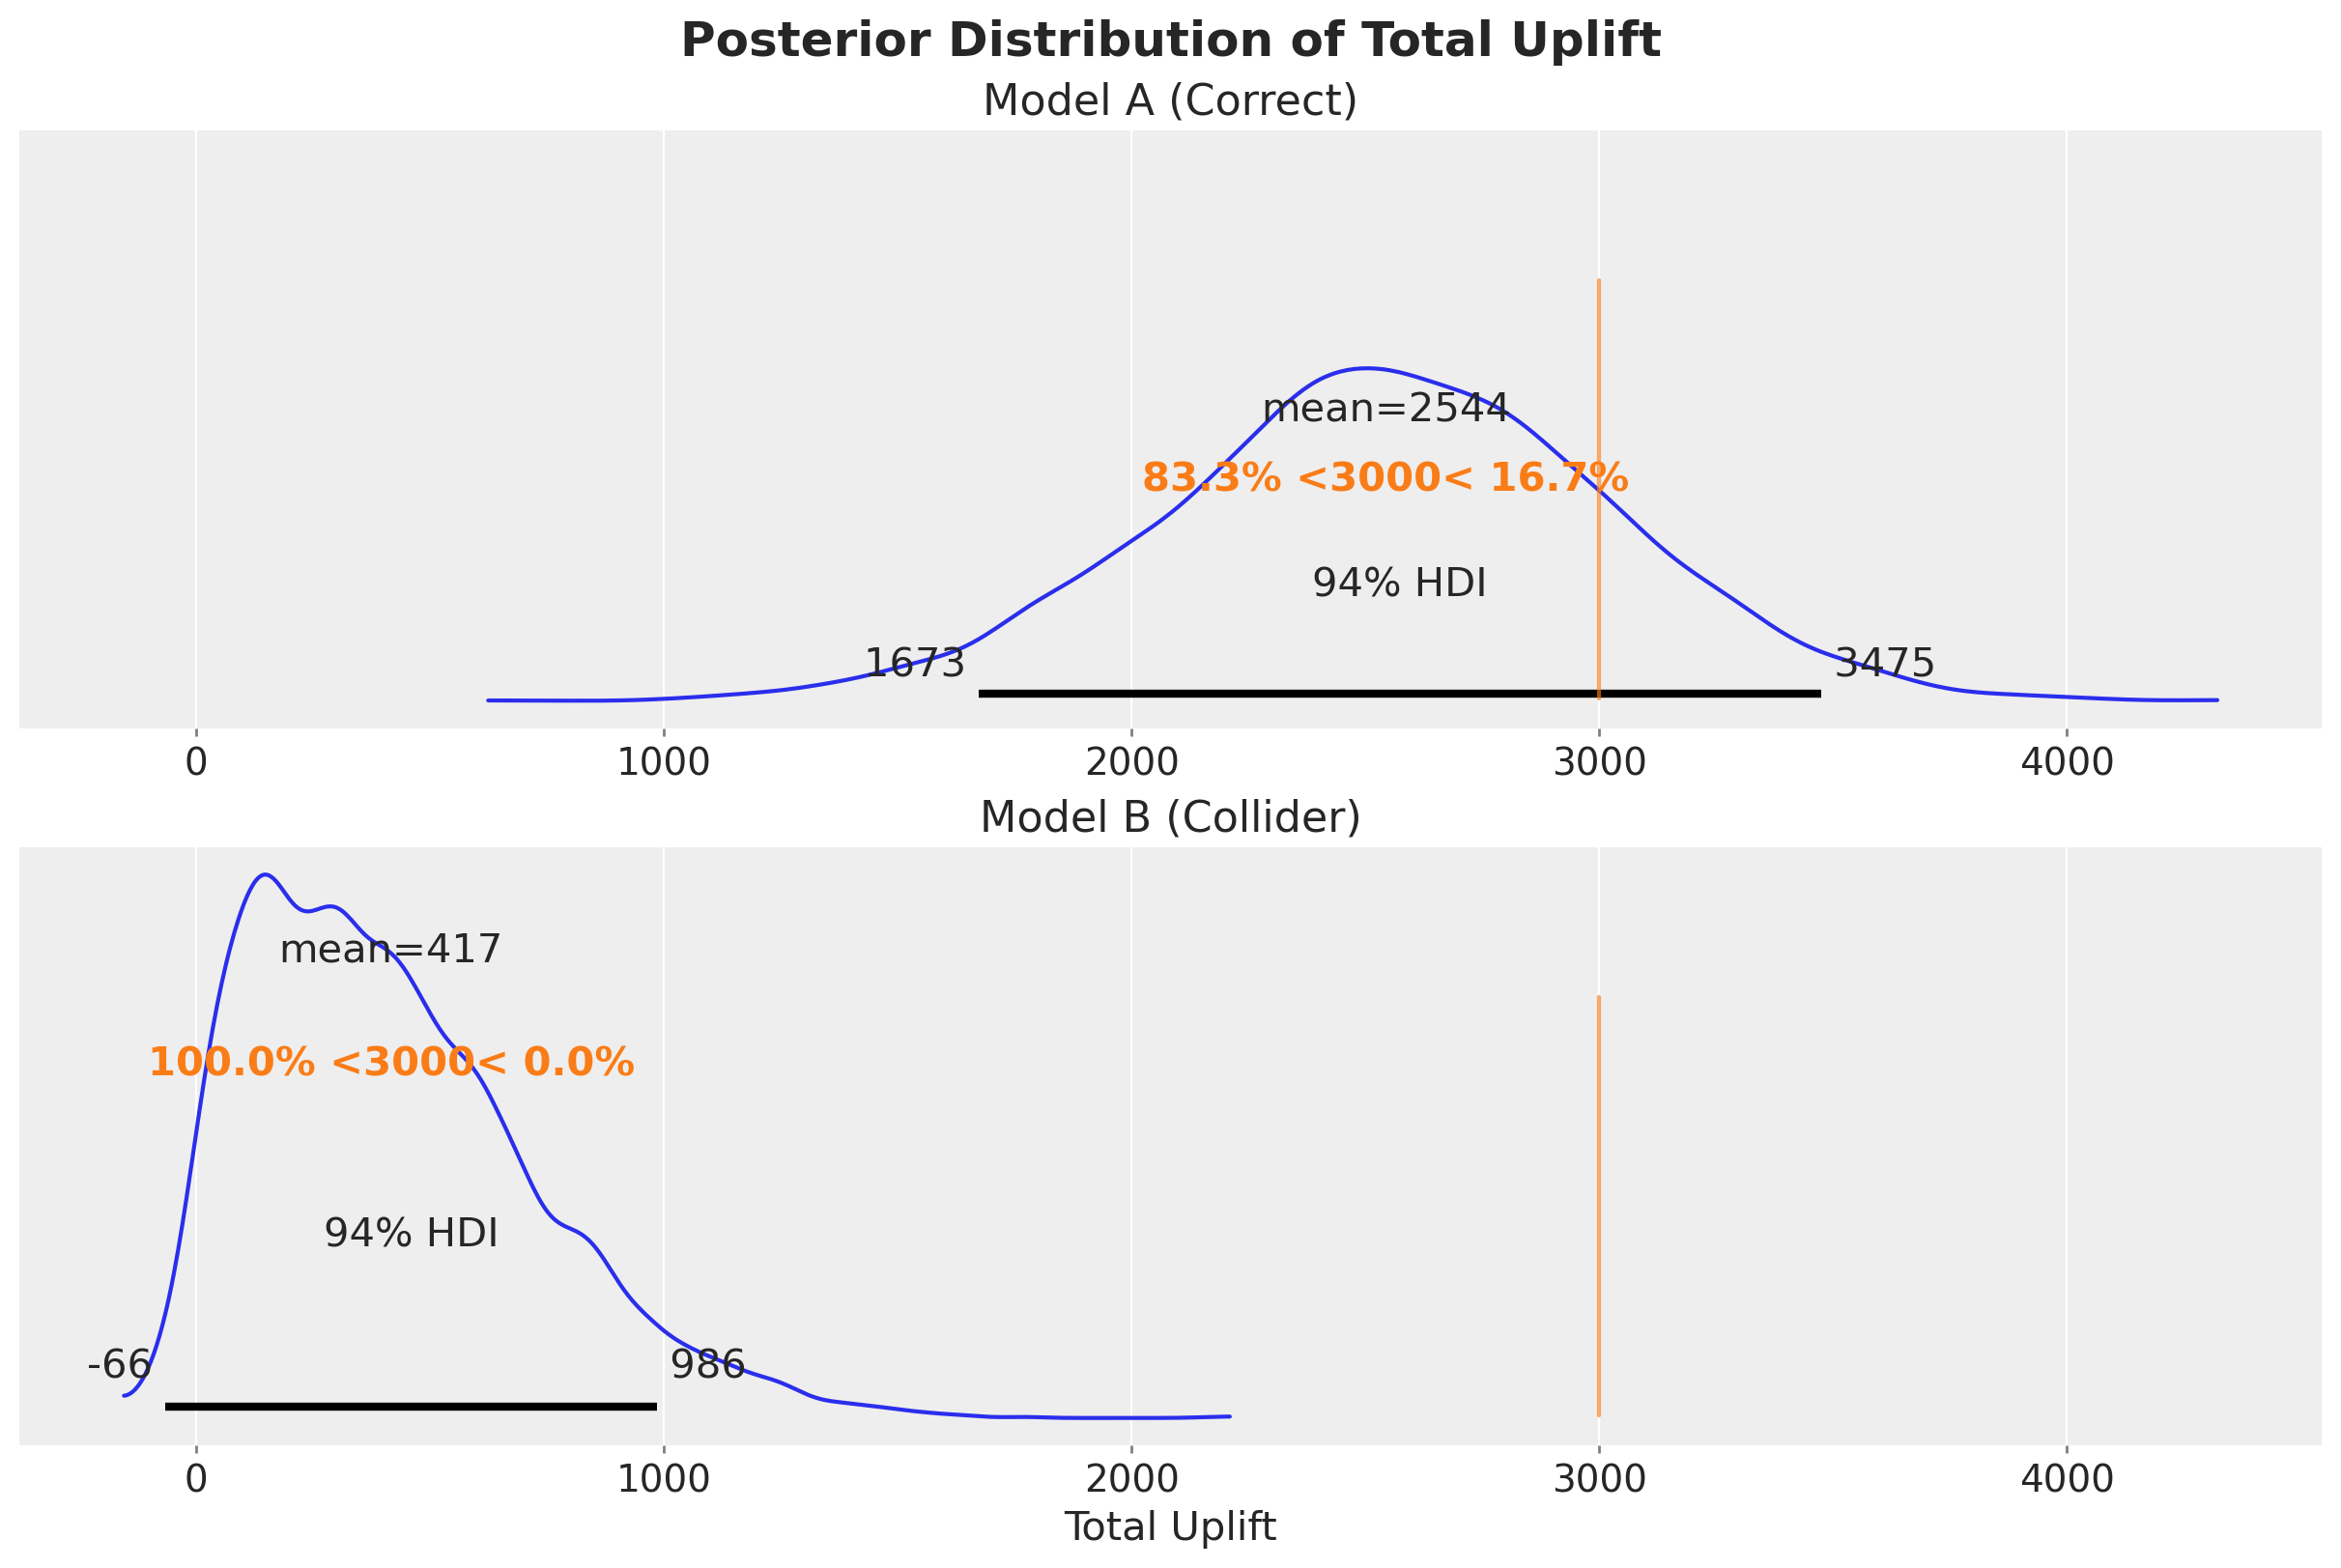

In [17]:
delta = 5

internvention_df_pd = df_pd.assign(spend=df_pd["spend"] + delta)

intervention_model_a = model_a.predict(
    idata_a, data=internvention_df_pd, kind="response", inplace=False
)
intervention_model_b = model_b.predict(
    idata_b, data=internvention_df_pd, kind="response", inplace=False
)


total_uplift_a = (
    (intervention_model_a["posterior_predictive"]["sales"] - df["sales"].to_numpy())
    .sum(dim="__obs__")
    .rename("total_uplift")
)

total_uplift_b = (
    (intervention_model_b["posterior_predictive"]["sales"] - df["sales"].to_numpy())
    .sum(dim="__obs__")
    .rename("total_uplift")
)

fig, axes = plt.subplots(
    nrows=2,
    ncols=1,
    figsize=(12, 8),
    sharex=True,
    sharey=True,
    layout="constrained",
)
az.plot_posterior(
    total_uplift_a, ref_val=delta * simulator.true_beta_spend * df.shape[0], ax=axes[0]
)
az.plot_posterior(
    total_uplift_b, ref_val=delta * simulator.true_beta_spend * df.shape[0], ax=axes[1]
)
axes[0].set(title="Model A (Correct)")
axes[1].set(title="Model B (Collider)", xlabel="Total Uplift")
fig.suptitle("Posterior Distribution of Total Uplift", fontsize=18, fontweight="bold");

We see that Model B is just very off from any reasonable answer (not even a "ballpark" estimate).

## Conclusion

This example illustrates a fundamental point: **in-sample $R^2$ measures predictive fit, not causal accuracy.**
For decision making (e.g., "how much should I spend on marketing?"), we need a model that correctly estimates the causal effect, not one that maximizes $R^2$. The structural causal model (Model A) answers the decision question correctly despite having a lower $R^2$.

This is not to say we should not care about $R^2$ and other in and out of sample metrics. The point is that these should not be the criteria for choosing a model to answer a decision question.